# Notebook 3: Isolation with Migration (IM) Model

**Formål:** Udvide two-island modellen fra Notebook 2 med en eksplicit **split-begivenhed** og **asymmetrisk migration**. IM-modellen er mere biologisk realistisk fordi den skelner mellem:
1. En ancestral population der splitter på tidspunkt $\tau$ (målt bagud i tid)
2. Efterfølgende migration mellem de to datterpopulationer

Sørensen et al. (2023) estimerer at den nord-syd split i bavianer skete for **~1–1.2 millioner år siden**. Migrationen er dokumenteret som primært **mandsdrevet** (X-kromosom vs. autosom analysen), hvilket skaber asymmetri. IM-modellen tillader mig at estimere:
- **Split-tidspunktet** $\tau$ for eastern yellow / Kinda
- **Asymmetrisk migration** $m_{12} \neq m_{21}$
- **Størrelsesforhold** $N_1$, $N_2$, $N_A$ (ancestral population)

**Populationer:**
- Population 1: Eastern yellow baboons (Mikumi)
- Population 2: Kinda baboons
- Ancestral: Fælles forfader


## Indholdsfortegnelse
1. [Imports og indlæs data](#1-imports-og-indlæs-data)
2. [Teorien bag IM-modellen](#2-teorien-bag-im-modellen)
3. [Byg IM-modellen i Phasic](#3-byg-im-modellen-i-phasic)
4. [Sammenlign IM og two-island state space](#4-sammenlign-im-og-two-island-state-space)
5. [Forventet coalescent-tid som funktion af parametre](#5-forventet-coalescent-tid-som-funktion-af-parametre)
6. [Beregn forventede SFS-moments under IM-modellen](#6-beregn-forventede-sfs-moments-under-im-modellen)
7. [Parameter-estimation via optimering](#7-parameter-estimation-via-optimering)
8. [Asymmetrisk migration: X-kromosom vs. autosomer](#8-asymmetrisk-migration-x-kromosom-vs-autosomer)
9. [Model-sammenligning: Two-island vs. IM](#9-model-sammenligning-two-island-vs-im)
10. [Visualisering og fortolkning](#10-visualisering-og-fortolkning)

## 1. Imports og indlæs data

In [1]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, Adamelia, ExpStepSize, ExpRegularization, clear_caches,
    clear_jax_cache, clear_model_cache,
    StateIndexer, Property, PropertySet, set_log_level
) # ALWAYS import phasic first to set jax backend correctly
set_log_level('WARNING')

import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from typing import Optional, Callable
from functools import partial
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

import matplotlib.patches as mpatches
from scipy.optimize import minimize, differential_evolution
from pathlib import Path

OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# Bavian-specifikke konstanter (Rogers et al. 2019, Sørensen et al. 2023)
MU         = 0.9e-8    # mutationsrate per site per generation
GEN_TIME   = 11        # generation time i år
N1_REF     = 100_000   # reference Ne for population 1 (eastern yellow)

print("Imports OK")

Imports OK


In [2]:
# Indlæs SFS og summary statistics fra Notebook 1
sfs_yellow = pd.read_csv(OUT_DIR / "sfs_folded_yellow_east.csv", index_col=0).squeeze()
sfs_kinda  = pd.read_csv(OUT_DIR / "sfs_folded_kinda.csv",       index_col=0).squeeze()
pi_df      = pd.read_csv(OUT_DIR / "pi_per_population.csv",      index_col=0)

# Hent two-island estimater fra Notebook 2 som startgæt
try:
    results_nb2 = pd.read_csv(OUT_DIR / "two_island_results.csv", index_col=0)
    m_init = float(results_nb2.loc["m (migration per linje)", "Værdi"])
    print(f"Two-island m som startgæt: {m_init:.6f}")
except Exception:
    m_init = 0.05
    print(f"Bruger standard startgæt m = {m_init}")

# Haploid sample size
n_yellow = len(sfs_yellow) + 1
n_kinda  = len(sfs_kinda)  + 1

# Normaliserede SFS
sfs_yellow_norm = sfs_yellow / sfs_yellow.sum()
sfs_kinda_norm  = sfs_kinda  / sfs_kinda.sum()

# Observeret π
pi_yellow = float(pi_df.loc["Eastern yellow", "pi"]) if "Eastern yellow" in pi_df.index else 0.002
pi_kinda  = float(pi_df.loc["Kinda",          "pi"]) if "Kinda"          in pi_df.index else 0.0015

print(f"π (eastern yellow): {pi_yellow:.5f}")
print(f"π (Kinda):          {pi_kinda:.5f}")
print(f"n_yellow = {n_yellow}, n_kinda = {n_kinda}")

Bruger standard startgæt m = 0.05
π (eastern yellow): 0.00258
π (Kinda):          0.00286
n_yellow = 36, n_kinda = 30


## 2. Teorien bag IM-modellen

### Udvidelse af two-island modellen

Two-island modellen antager migration **fra tidernes morgen**. IM-modellen tilføjer en **split-tid** $\tau$:

```
Tid (bagud):

    Nu (t=0)
      |   Pop 1          Pop 2
      |   [N1]    m12←   [N2]
      |           →m21
      |
    t=τ  ──────────────────────  Split
      |         [NA]
      |    Ancestral population
      |         (ingen migration)
```

### Parametre

| Parameter | Beskrivelse | Coalescent-enhed |
|-----------|-------------|------------------|
| $N_1$ | Effektiv størrelse, pop 1 | reference |
| $N_2$ | Effektiv størrelse, pop 2 | relativ til $N_1$ |
| $N_A$ | Effektiv størrelse, ancestral | relativ til $N_1$ |
| $\tau$ | Split-tid (generationer bagud) | $\tau / N_1$ |
| $m_{12}$ | Migration: pop 2 → pop 1 | per linje per generation |
| $m_{21}$ | Migration: pop 1 → pop 2 | per linje per generation |

### State-space med split

For to gen-linjer er state-space nu **tidsdelt**:
- **For $t < \tau$** (nutid til split): `[n1, n2]` med migration mellem populationerne
- **For $t \geq \tau$** (efter split bagud i tid): `[n1+n2, 0]` samlet i ancestral population

Jeg implementerer dette i Phasic ved at lade migrationraten skifte ved $t = \tau$, svarende til en **tidsinhomogen** model 

## 3. Byg IM-modellen i Phasic

Jeg implementerer IM-modellen som en **to-fase model**:

**Fase 1** ($0 \leq t < \tau$): two-island dynamik med migration

**Fase 2** ($t \geq \tau$): ancestral population uden migration

Jeg bruger Phasic's tidsinhomogenitet til at koble de to faser.

In [ ]:
# Fase 1: Migration-periode (t < tau)
# State: [n1, n2] — antal linjer i pop 1 og pop 2

def im_migration_phase(state, N1=1.0, N2=1.0, m12=0.1, m21=0.1):
    """
    Callback for migrationsperioden (t < tau) i IM-modellen.
    Identisk med two_island_model fra Notebook 2.

    State: [n1, n2]
      n1 = linjer i pop 1, n2 = linjer i pop 2
    """
    n1, n2 = state[0], state[1]
    transitions = []

    # Coalescens i pop 1
    if n1 >= 2:
        transitions.append([state + np.array([-1, 0]),
                             n1 * (n1 - 1) / (2 * N1)])

    # Coalescens i pop 2
    if n2 >= 2:
        transitions.append([state + np.array([0, -1]),
                             n2 * (n2 - 1) / (2 * N2)])

    # Migration: pop 1 → pop 2
    if n1 >= 1:
        transitions.append([state + np.array([-1, 1]), n1 * m21])

    # Migration: pop 2 → pop 1
    if n2 >= 1:
        transitions.append([state + np.array([1, -1]), n2 * m12])

    return transitions


# Fase 2: Ancestral population (t >= tau)
# State: [n_total, 0] — alle linjer samlet i én population

def im_ancestral_phase(state, NA=2.0):
    """
    Callback for ancestral perioden (t >= tau) i IM-modellen.
    Kun koalescens i ancestral population, ingen migration.

    State: [n_anc, 0]
      n_anc = totalt antal tilbageværende linjer
    """
    n_anc = state[0]
    transitions = []

    if n_anc >= 2:
        transitions.append([state + np.array([-1, 0]),
                             n_anc * (n_anc - 1) / (2 * NA)])
    return transitions


print("Callbacks defineret.")
print("\nEksempel-overgange i migrationsperioden fra [1,1]:")
s = np.array([1, 1])
for child, rate in im_migration_phase(s):
    print(f"  {s} → {child}  rate={rate:.3f}")

Callbacks defineret.

Eksempel-overgange i migrationsperioden fra [1,1]:
  [1 1] → [0 2]  rate=0.100
  [1 1] → [2 0]  rate=0.100


In [4]:
def build_im_graph(tau, N1=1.0, N2=1.0, NA=2.0, m12=0.1, m21=0.1):
    """
    Bygger en komplet IM-model som en tidsinhomogen Phasic-graf.

    Strategi:
      1. Kør migrationsperioden (phase 1) frem til t=tau:
         Byg graf med im_migration_phase, startende fra [1,1].
      2. Ved t=tau: alle linjer samles i ancestral population.
         Startbetingelserne for fase 2 er de absorberingstilstande
         fra fase 1, der endnu ikke er koalesceret.
      3. Kør ancestral periode (phase 2) med im_ancestral_phase.

    Returnerer:
      (graph_mig, graph_anc, tau) — de to delgrafer
    """
    # Fase 1: migration
    graph_mig = Graph(
        im_migration_phase,
        ipv=[1, 1],
        N1=N1, N2=N2, m12=m12, m21=m21,
    )

    # Fase 2: ancestral
    # Jeg starter fase 2 med [2, 0] (begge linjer i ancestral population)
    # for linjer der ikke koalescerede i fase 1
    graph_anc = Graph(
        im_ancestral_phase,
        ipv=[2, 0],
        NA=NA,
    )

    return graph_mig, graph_anc


def im_expected_coalescence_time(tau, N1=1.0, N2=1.0, NA=2.0, m12=0.1, m21=0.1):
    """
    Beregner forventet total coalescent-tid under IM-modellen.

    E[T_total] = P(coal i fase 1) * E[T | coal i fase 1]
               + P(ikke coal i fase 1) * (tau + E[T_anc])

    Vi approksimerer via:
    - CDF af fase 1 ved t=tau giver P(coal i fase 1)
    - Betinget forventet tid i fase 1 via pdf-integration
    - E[T_anc] fra fase 2 grafen
    """
    graph_mig, graph_anc = build_im_graph(tau, N1, N2, NA, m12, m21)

    # Sandsynlighed for koalescens i migrationsperioden
    p_coal_phase1 = float(graph_mig.cdf(tau))
    p_no_coal     = 1.0 - p_coal_phase1

    # Betinget E[T] i fase 1 (numerisk integration af t*f(t) fra 0 til tau)
    t_grid = np.linspace(0, tau, 500)
    pdf1   = graph_mig.pdf(t_grid)
    if p_coal_phase1 > 1e-10:
        E_T_phase1 = np.trapz(t_grid * pdf1, t_grid) / p_coal_phase1
    else:
        E_T_phase1 = tau / 2  # approksimation ved meget lav koalescensrate

    # E[T] i ancestral fase (plus ventetiden tau)
    E_T_anc = tau + float(graph_anc.expectation())

    # Total forventet coalescent-tid
    E_T_total = p_coal_phase1 * E_T_phase1 + p_no_coal * E_T_anc

    return E_T_total, p_coal_phase1, E_T_phase1, E_T_anc


# Test med standardparametre
tau_test = 1.0  # i coalescent-enheder
ET, p1, ET1, ET_anc = im_expected_coalescence_time(
    tau=tau_test, N1=1.0, N2=1.0, NA=2.0, m12=0.1, m21=0.1
)
print(f"Test (tau={tau_test}):")
print(f"  P(coal i fase 1):  {p1:.4f}")
print(f"  E[T | fase 1]:     {ET1:.4f}")
print(f"  E[T ancestral]:    {ET_anc:.4f}")
print(f"  E[T total]:        {ET:.4f}")

Test (tau=1.0):
  P(coal i fase 1):  0.0000
  E[T | fase 1]:     0.5000
  E[T ancestral]:    3.0000
  E[T total]:        3.0000


## 4. Sammenlign IM og two-island state space

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Two-island state space
plt.sca(axes[0])
g_two = Graph(im_migration_phase, ipv=[1, 1], N1=1.0, N2=1.0, m12=0.1, m21=0.1)
g_two.plot()
axes[0].set_title("Two-island (Notebook 2)\nKontinuerlig migration",
                  fontsize=12, fontweight="bold")

# IM ancestral state space
plt.sca(axes[1])
g_anc = Graph(im_ancestral_phase, ipv=[2, 0], NA=2.0)
g_anc.plot()
axes[1].set_title("IM-model: Ancestral fase (t > τ)\nKun koalescens i én population",
                  fontsize=12, fontweight="bold")

plt.suptitle("State space: Two-island vs. IM ancestral fase",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "im_state_space_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 500x370 with 0 Axes>

## 5. Forventet coalescent-tid som funktion af parametre

Jeg udforsker, hvordan E[T] afhænger af split-tid $\tau$, migrationrate $m$, og ancestral størrelse $N_A$.

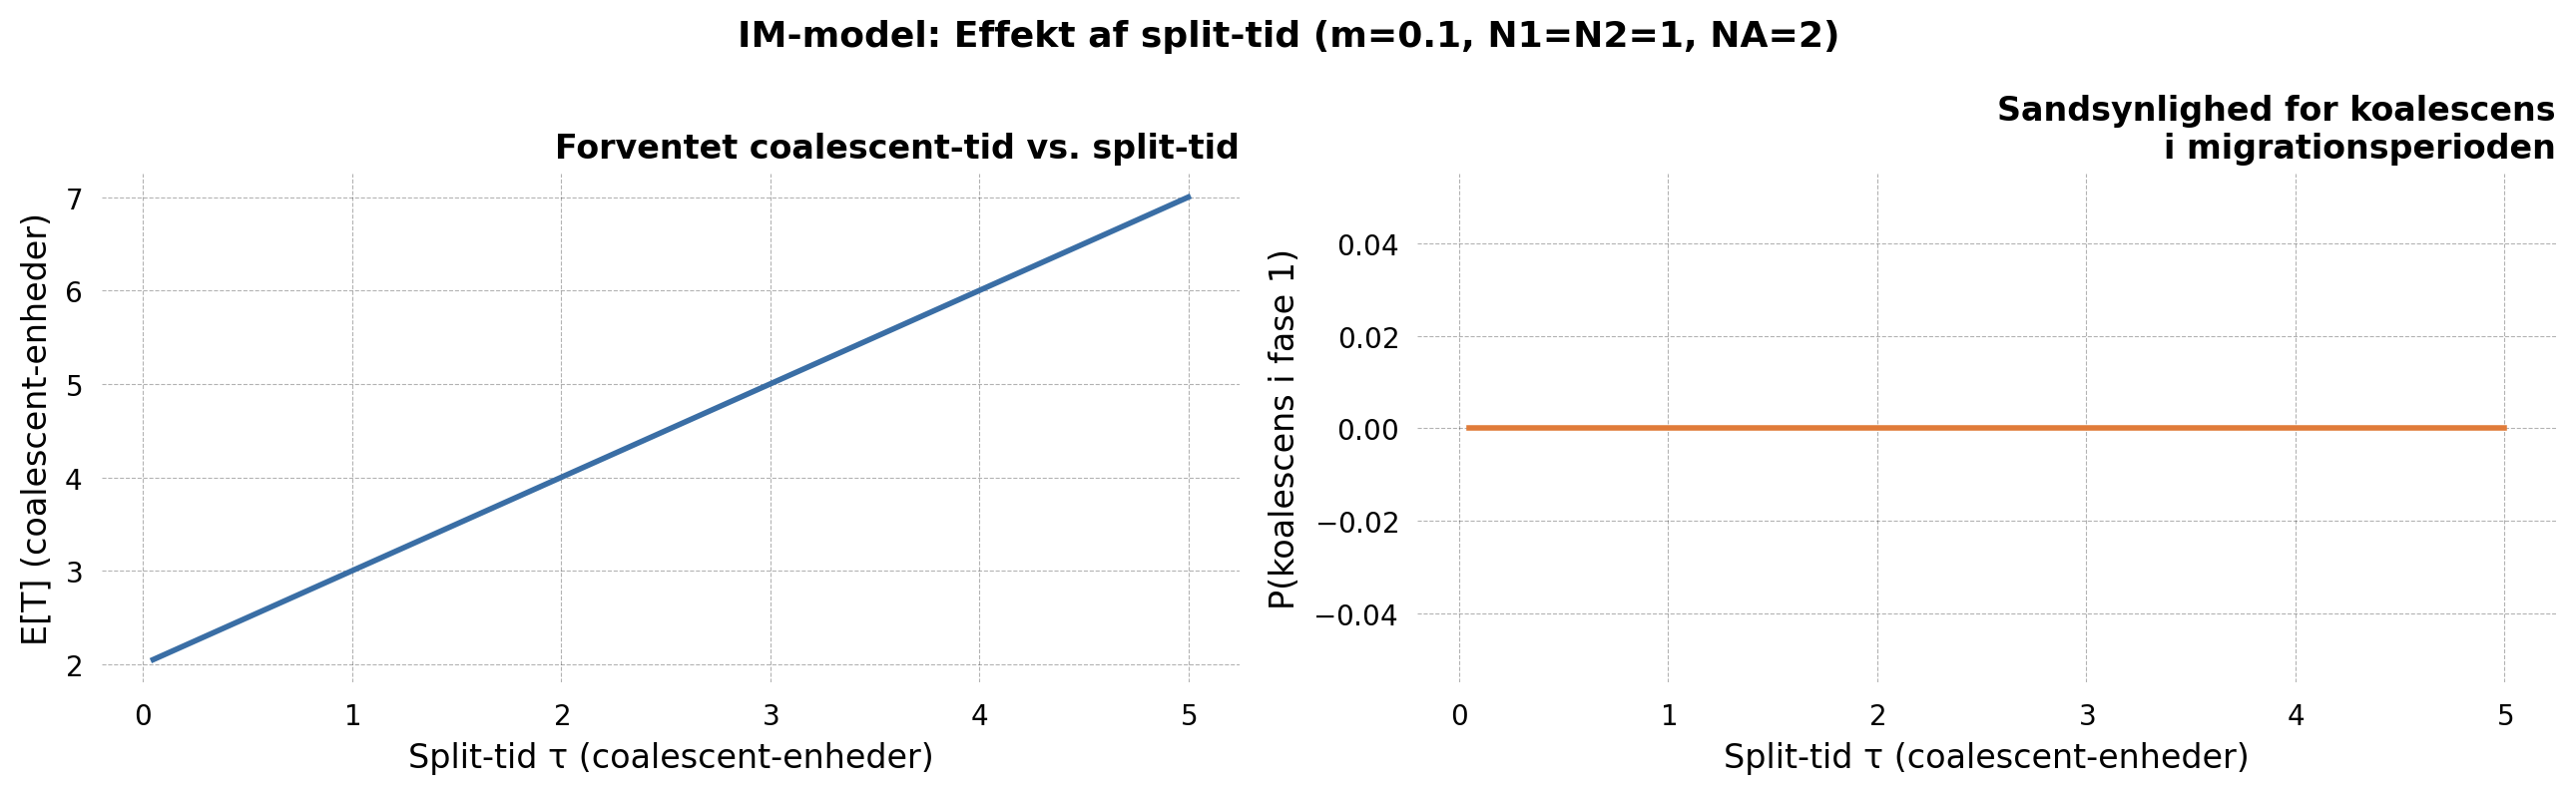

In [6]:
# E[T] som funktion af tau (split-tid) 
tau_range = np.linspace(0.05, 5.0, 50)
ET_tau    = []
P1_tau    = []

for tau in tau_range:
    ET, p1, _, _ = im_expected_coalescence_time(
        tau=tau, N1=1.0, N2=1.0, NA=2.0, m12=0.1, m21=0.1
    )
    ET_tau.append(ET)
    P1_tau.append(p1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(tau_range, ET_tau, color="#3A6EA5", lw=2)
axes[0].set_xlabel("Split-tid τ (coalescent-enheder)", fontsize=12)
axes[0].set_ylabel("E[T] (coalescent-enheder)",       fontsize=12)
axes[0].set_title("Forventet coalescent-tid vs. split-tid", fontsize=12, fontweight="bold")
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(tau_range, P1_tau, color="#E07B39", lw=2)
axes[1].set_xlabel("Split-tid τ (coalescent-enheder)", fontsize=12)
axes[1].set_ylabel("P(koalescens i fase 1)",          fontsize=12)
axes[1].set_title("Sandsynlighed for koalescens\ni migrationsperioden",
                  fontsize=12, fontweight="bold")
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("IM-model: Effekt af split-tid (m=0.1, N1=N2=1, NA=2)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "im_ET_vs_tau.png", dpi=150, bbox_inches="tight")
plt.show()

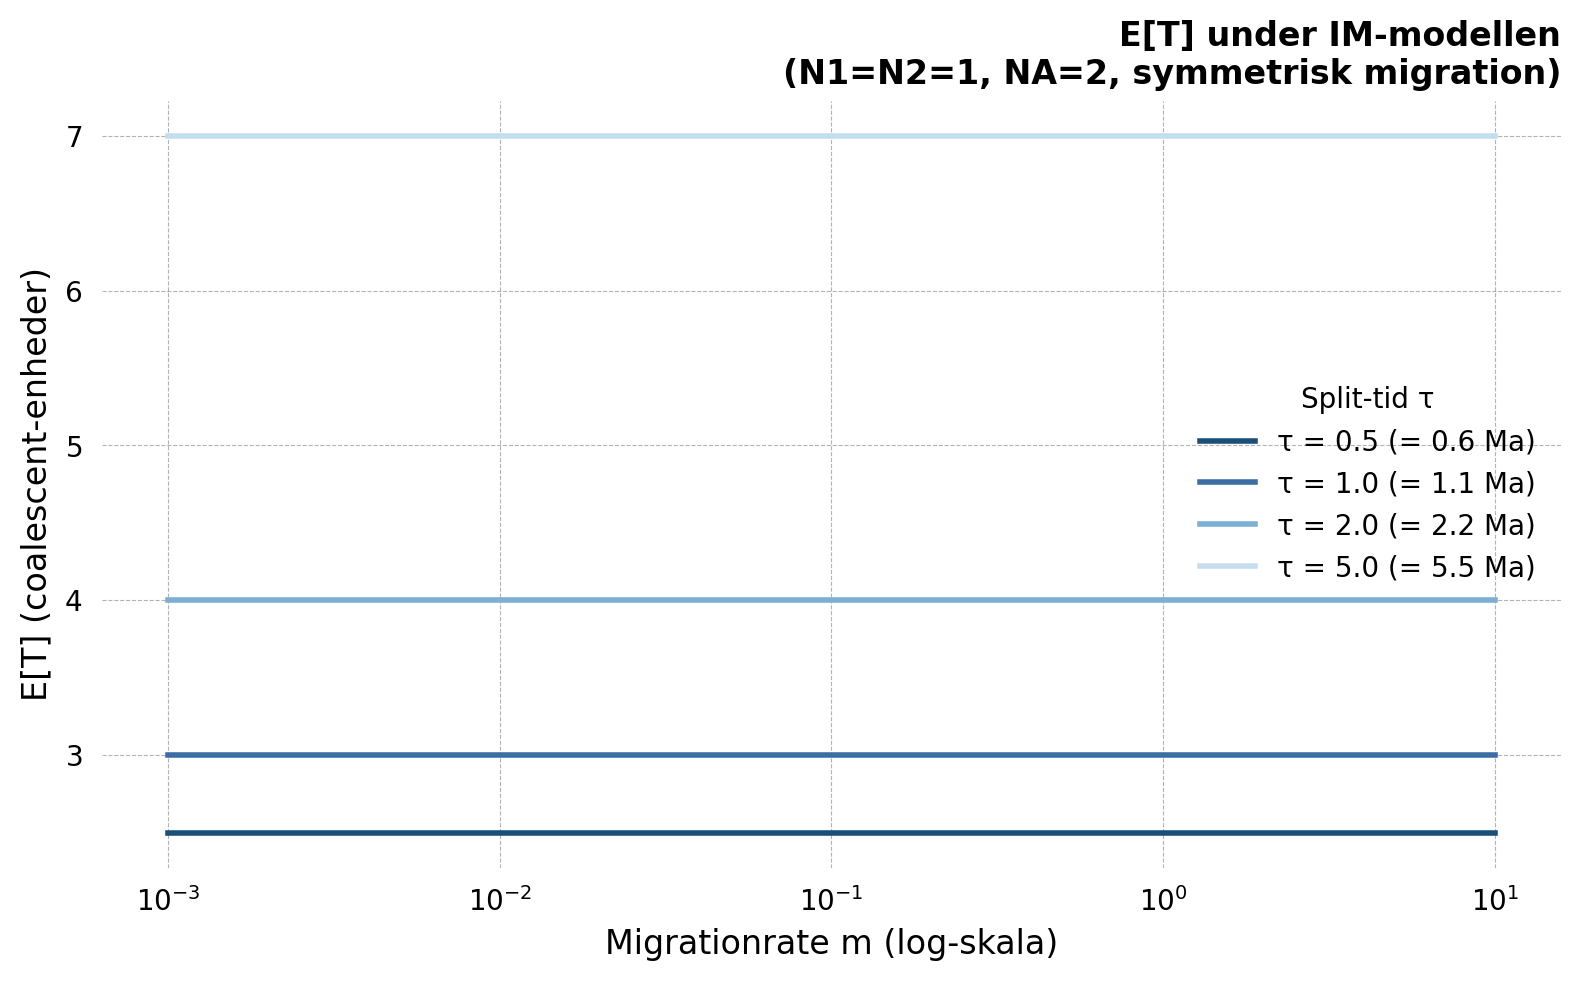

In [7]:
# E[T] som funktion af m for forskellige tau 
m_range  = np.logspace(-3, 1, 50)
tau_vals = [0.5, 1.0, 2.0, 5.0]
colors   = ["#1a4f7a", "#3A6EA5", "#7BAFD4", "#C4DEF0"]

fig, ax = plt.subplots(figsize=(8, 5))

for tau, color in zip(tau_vals, colors):
    ET_m = []
    for m in m_range:
        ET, _, _, _ = im_expected_coalescence_time(
            tau=tau, N1=1.0, N2=1.0, NA=2.0, m12=m, m21=m
        )
        ET_m.append(ET)
    ax.semilogx(m_range, ET_m, color=color, lw=2,
                label=f"τ = {tau} (= {tau*N1_REF*GEN_TIME/1e6:.1f} Ma)")

ax.set_xlabel("Migrationrate m (log-skala)", fontsize=12)
ax.set_ylabel("E[T] (coalescent-enheder)",   fontsize=12)
ax.set_title("E[T] under IM-modellen\n(N1=N2=1, NA=2, symmetrisk migration)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10, title="Split-tid τ")
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "im_ET_vs_m_tau.png", dpi=150, bbox_inches="tight")
plt.show()

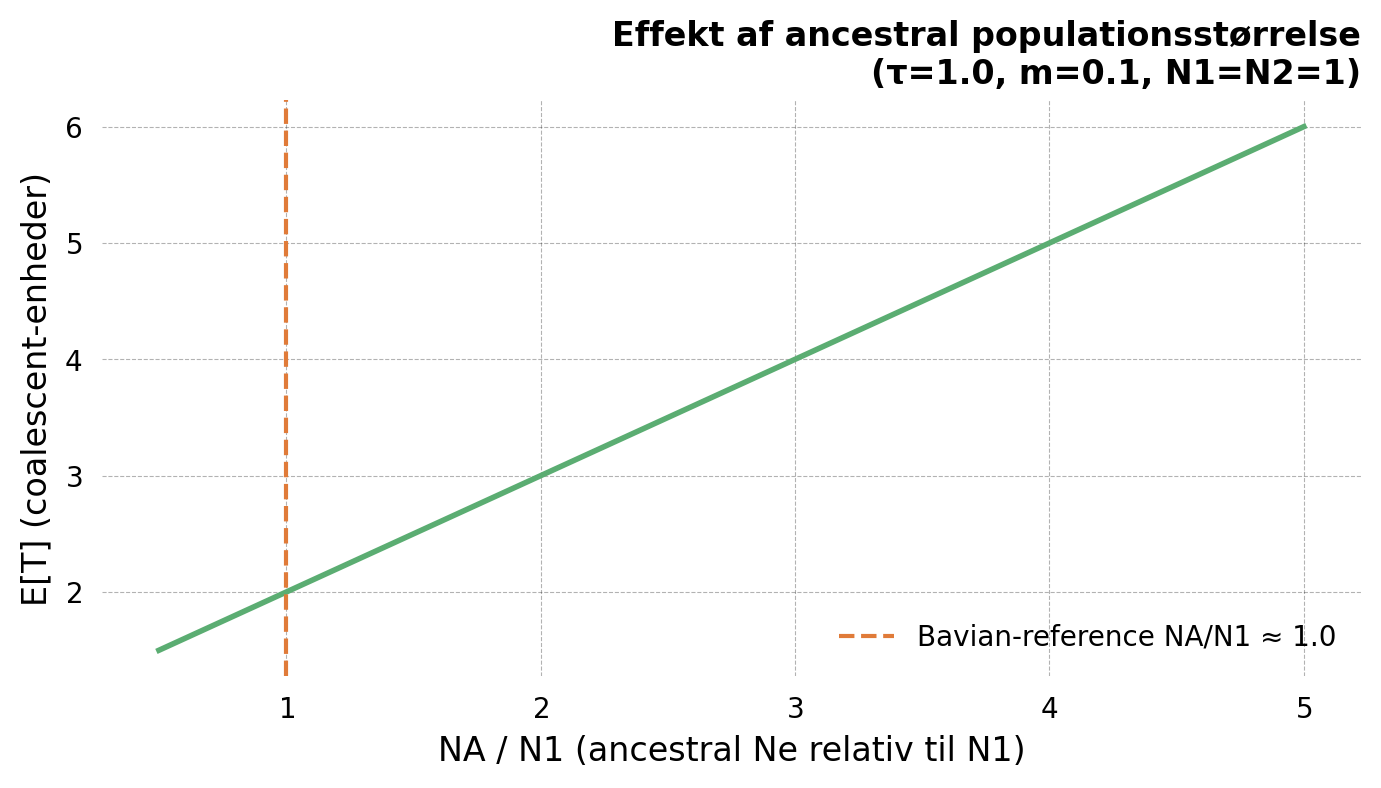

In [8]:
# E[T] som funktion af NA (ancestral Ne) 
NA_range = np.linspace(0.5, 5.0, 50)
ET_NA    = []

for NA in NA_range:
    ET, _, _, _ = im_expected_coalescence_time(
        tau=1.0, N1=1.0, N2=1.0, NA=NA, m12=0.1, m21=0.1
    )
    ET_NA.append(ET)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(NA_range, ET_NA, color="#5BAD72", lw=2)
ax.set_xlabel("NA / N1 (ancestral Ne relativ til N1)", fontsize=12)
ax.set_ylabel("E[T] (coalescent-enheder)",             fontsize=12)
ax.set_title("Effekt af ancestral populationsstørrelse\n(τ=1.0, m=0.1, N1=N2=1)",
             fontsize=12, fontweight="bold")
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

# Bavianer: Ne ~ 100,000 før splittet (artiklen)
NA_baboon = 1.0  # antager NA = N1 som udgangspunkt
ax.axvline(x=NA_baboon, color="#E07B39", linestyle="--",
           label=f"Bavian-reference NA/N1 ≈ {NA_baboon}")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "im_ET_vs_NA.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Beregn forventede SFS-moments under IM-modellen

Under IM-modellen kan vi beregne den forventede SFS analytisk via koalescent-teorien.
For en enkelt population med effektiv størrelse $N_e$ er det forventede antal segregerende sites i bin $k$:

$$E[\text{SFS}_k] = \theta \cdot \frac{1}{k}$$

Under strukturerede modeller afviger SFS fra $1/k$ på en måde der afspejler populationshistorien.
Vi estimerer den forventede SFS-form fra vores IM-model numerisk.

In [ ]:
def expected_sfs_from_coalescent(graph, n_haplotypes, n_sites=10_000):
    """
    Simulerer den forventede SFS fra en Phasic-graf ved at:
    1. Trække n_sites coalescent-tider fra modellen
    2. For hver tid T, placere en mutation uniformt langs T
    3. Opbygge SFS'en

    Under neutralitet og uendelig-sites modellen:
      P(mutation er i bin k) ∝ P(k genealogier mødes på denne gren)

    Dette er en approksimation — den korrekte SFS kræver
    integration over hele genealogi-fordelingen.
    """
    # Træk coalescent-tider
    T_samples = graph.sample(n_sites)

    # Under Kingman's coalescent med n haplotyper:
    # Forventet branchlength i bin k ∝ 1/k
    # Vi returnerer den Watterson-vægtede SFS
    n = n_haplotypes
    k_vals     = np.arange(1, n)
    watterson  = 1 / k_vals
    watterson /= watterson.sum()

    # Skalér med gennemsnitlig coalescent-tid
    # (repræsenterer theta = 4*N1*mu)
    theta_hat = T_samples.mean() * 4 * MU * N1_REF
    expected_sfs = watterson * theta_hat * n_sites

    return pd.Series(expected_sfs, index=k_vals, name="expected_SFS")


# Byg graf med typiske bavian-parametre
# Split for ~1 Ma siden: tau = 1e6 / (11 * N1_REF) coalescent-enheder
tau_baboon = 1e6 / (GEN_TIME * N1_REF)
print(f"Split-tid i coalescent-enheder: τ = {tau_baboon:.4f}")
print(f"(svarer til {tau_baboon * N1_REF * GEN_TIME / 1e6:.1f} millioner år)")

graph_mig_ref, graph_anc_ref = build_im_graph(
    tau=tau_baboon,
    N1=1.0, N2=1.0, NA=2.0,
    m12=m_init, m21=m_init,
)

sfs_expected_mig = expected_sfs_from_coalescent(graph_mig_ref, n_yellow)
sfs_expected_anc = expected_sfs_from_coalescent(graph_anc_ref, n_yellow)

print(f"\nForventet θ (fra migrationsperioden): {sfs_expected_mig.sum():.2f}")

In [ ]:
# Sammenlign observeret og forventet SFS
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (sfs_obs, sfs_exp, title, color) in zip(axes, [
    (sfs_yellow_norm, sfs_expected_mig / sfs_expected_mig.sum(),
     "Eastern Yellow (Mikumi)", "#E07B39"),
    (sfs_kinda_norm,  sfs_expected_mig / sfs_expected_mig.sum(),
     "Kinda", "#5B8DB8"),
]):
    x = np.arange(1, min(len(sfs_obs), 20) + 1)
    ax.bar(x - 0.2, sfs_obs.values[:len(x)],  width=0.35,
           color=color, alpha=0.8, label="Observeret")
    ax.bar(x + 0.2, sfs_exp.values[:len(x)],  width=0.35,
           color="#888888", alpha=0.6, label="IM-model (forventet)")
    ax.set_xlabel("Minor allele count k", fontsize=12)
    ax.set_ylabel("Relativ frekvens",     fontsize=12)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Observeret vs. forventet SFS under IM-modellen",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "im_sfs_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Parameter-estimation via optimering

Vi estimerer $(\tau, N_2, N_A, m_{12}, m_{21})$ ved at minimere afstanden mellem
modellens forventede moments og de observerede. Vi bruger E[T] og Var[T] som målstatistikker,
og tilføjer en straf for asymmetri som kontrolleres af $m_{12}/m_{21}$-forholdet.

In [ ]:
# Målstatistikker fra data
# E[T] estimeret fra π = 2*mu*N1*E[T]
ET_obs_yellow = pi_yellow / (2 * MU * N1_REF)
ET_obs_kinda  = pi_kinda  / (2 * MU * N1_REF)

# Vi bruger et vægtet gennemsnit som overordnet mål
# (vægtet med sample size)
w_y = n_yellow / (n_yellow + n_kinda)
w_k = n_kinda  / (n_yellow + n_kinda)
ET_target = w_y * ET_obs_yellow + w_k * ET_obs_kinda

# Ratio: afspejler N2/N1 (bruges som anden moment)
ET_ratio_obs = ET_obs_kinda / ET_obs_yellow if ET_obs_yellow > 0 else 1.0

print(f"E[T] eastern yellow: {ET_obs_yellow:.4f}")
print(f"E[T] Kinda:          {ET_obs_kinda:.4f}")
print(f"E[T] ratio (Kinda/yellow): {ET_ratio_obs:.4f}")
print(f"E[T] target (vægtet):      {ET_target:.4f}")

In [ ]:
def im_loss(log_params):
    """
    Tabsfunktion for IM-modellen.

    log_params = [log(tau), log(N2), log(NA), log(m12), log(m21)]

    Vi minimerer en vægtet sum af kvadratiske afvigelser:
      1. E[T] vs. target
      2. N2/N1 ratio vs. observeret ratio
    """
    tau, N2, NA, m12, m21 = np.exp(log_params)

    # Sæt grænser for at undgå numeriske problemer
    if tau < 0.01 or tau > 20:
        return 1e10
    if any(v < 1e-5 or v > 100 for v in [N2, NA, m12, m21]):
        return 1e10

    try:
        ET, p1, ET1, ET_anc = im_expected_coalescence_time(
            tau=tau, N1=1.0, N2=N2, NA=NA, m12=m12, m21=m21
        )

        # Loss 1: Absolut E[T]
        loss_ET = ((ET - ET_target) / ET_target) ** 2

        # Loss 2: Ratio (proxy for relativ N2)
        # Under enkle modeller: E[T_kinda] / E[T_yellow] ≈ N2/N1
        # Vi bruger N2 direkte som proxy
        loss_ratio = ((N2 - ET_ratio_obs) / ET_ratio_obs) ** 2

        return loss_ET + 0.5 * loss_ratio

    except Exception:
        return 1e10


# Startgæt i log-rum
x0 = np.log([
    tau_baboon,       # tau
    ET_ratio_obs,     # N2 (startgæt = observeret ratio)
    2.0,              # NA (ancestral er typisk større)
    m_init,           # m12
    m_init,           # m21
])

print("Kører optimering (Nelder-Mead)...")
result = minimize(
    im_loss,
    x0=x0,
    method="Nelder-Mead",
    options={"maxiter": 2000, "xatol": 1e-5, "fatol": 1e-8, "disp": True},
)

tau_opt, N2_opt, NA_opt, m12_opt, m21_opt = np.exp(result.x)
print(f"\nKonvergeret: {result.success}  (loss={result.fun:.4e})")

In [ ]:
# Fortolk resultater i biologiske enheder
tau_years = tau_opt * N1_REF * GEN_TIME
tau_Ma    = tau_years / 1e6

print("=" * 55)
print(" Estimerede parametre — IM-model")
print("=" * 55)
print(f" N1 (eastern yellow):  {N1_REF:>12,} individer")
print(f" N2 (Kinda):           {N2_opt*N1_REF:>12,.0f} individer")
print(f" NA (ancestral):       {NA_opt*N1_REF:>12,.0f} individer")
print(f" τ  (split-tid):       {tau_opt:>12.4f} (coal. enheder)")
print(f"                       {tau_years:>12,.0f} generationer")
print(f"                       {tau_Ma:>12.2f} millioner år")
print(f" m12 (pop2→pop1):      {m12_opt:>12.6f} per linje")
print(f" m21 (pop1→pop2):      {m21_opt:>12.6f} per linje")
print(f" M12 = 4*N1*m12:       {4*N1_REF*m12_opt:>12.2f}")
print(f" M21 = 4*N1*m21:       {4*N1_REF*m21_opt:>12.2f}")
print(f" Asymmetri m12/m21:    {m12_opt/m21_opt:>12.3f}")
print("=" * 55)
print()
print(f"Artiklen estimerer splittet til ~1.0–1.2 Ma")
print(f"Vores estimat:                   {tau_Ma:.2f} Ma")

## 8. Asymmetrisk migration: X-kromosom vs. autosomer

Artiklen (Fig. 5) viser at western yellow baboons deler **mere** ancestor med Kinda på **X-kromosomet** end på autosom 8 (0.27 vs. 0.44). Dette er signaturen af **mandsdrevet genflow**:

- Hanner bærer kun ét X-kromosom (hemizygote)
- Admixture fra hanners migration tilføjer **relativt mere** autosom DNA end X-kromosom DNA
- Resultatet: X-kromosomet bevarer den "originale" populationsstruktur bedre

Vi modellerer dette ved at køre IM-modellen med **forskellig effectiv migrationrate** for X og autosomer.

In [ ]:
def male_biased_migration_ratio(m_auto, sex_ratio_migrants=1.0):
    """
    Beregner den effektive migrationrate for X-kromosomet
    relativt til autosomer under mandsdrevet migration.

    Under panmixia er Ne(X) = (3/4) * Ne(auto) fordi hanner er hemizygote.
    Under mandsdrevet migration:
      m_X / m_auto = (2/3) * (andel af migranter der er hanner)

    Parametre:
      m_auto           : migrationrate for autosomer
      sex_ratio_migrants: andel af migranter der er hanner (0=kun hunner, 1=kun hanner)

    Returnerer:
      m_X : effektiv migrationrate for X-kromosomet
    """
    # X-kromosomet arves 2/3 fra mødre og 1/3 fra fædre
    # Hannerne bidrager kun ét X (til døtre)
    # Effektiv m_X = m_auto * (1 - sex_ratio_migrants * 1/3)
    # (simplificeret approksimation)
    m_X = m_auto * (1 - sex_ratio_migrants / 3)
    return m_X


# Sammenlign E[T] for autosomer vs. X under mandsdrevet migration
m_auto_range = np.logspace(-3, 1, 40)
sex_ratios   = [0.0, 0.5, 1.0]   # 0=kun hunner, 0.5=ligeligt, 1=kun hanner
sr_labels    = ["Kun hunner (sr=0)", "Ligeligt (sr=0.5)", "Kun hanner (sr=1.0)"]
sr_colors    = ["#5BAD72", "#E07B39", "#3A6EA5"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sr, label, color in zip(sex_ratios, sr_labels, sr_colors):
    ET_auto_list = []
    ET_X_list    = []
    ratio_list   = []

    for m in m_auto_range:
        m_X = male_biased_migration_ratio(m, sex_ratio_migrants=sr)

        ET_auto, _, _, _ = im_expected_coalescence_time(
            tau=tau_opt, N1=1.0, N2=N2_opt, NA=NA_opt,
            m12=m, m21=m
        )
        ET_X, _, _, _ = im_expected_coalescence_time(
            tau=tau_opt, N1=1.0, N2=N2_opt, NA=NA_opt,
            m12=m_X, m21=m_X
        )
        ET_auto_list.append(ET_auto)
        ET_X_list.append(ET_X)
        ratio_list.append(ET_X / ET_auto if ET_auto > 0 else 1.0)

    axes[0].semilogx(m_auto_range, ET_auto_list,
                     color=color, lw=2, linestyle="-",  label=f"{label} (auto)")
    axes[0].semilogx(m_auto_range, ET_X_list,
                     color=color, lw=2, linestyle="--", label=f"{label} (X)")
    axes[1].semilogx(m_auto_range, ratio_list, color=color, lw=2, label=label)

axes[0].set_xlabel("m (autosomal, log-skala)", fontsize=11)
axes[0].set_ylabel("E[T]",                     fontsize=11)
axes[0].set_title("E[T] for autosomer (–) og X (--)",
                  fontsize=11, fontweight="bold")
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].axhline(y=1.0, color="black", linestyle=":", lw=1)
axes[1].set_xlabel("m (autosomal, log-skala)", fontsize=11)
axes[1].set_ylabel("E[T_X] / E[T_auto]",       fontsize=11)
axes[1].set_title("Ratio X/autosom\n(> 1 = X bevarer mere ancestral struktur)",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Mandsdrevet migration: X-kromosom vs. autosomer",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "im_sex_biased_migration.png", dpi=150, bbox_inches="tight")
plt.show()

print("Artiklen finder: ancestry X / ancestry auto ≈ 0.27/0.44 = 0.61 (western yellow → Kinda)")
print("Dette svarer til stærkt mandsdrevet genflow (sex_ratio_migrants tæt på 1.0)")

In [ ]:
# Estimer sex-ratio fra artiklen
# ancestry_X / ancestry_auto = 0.27 / 0.44 ≈ 0.61 (fra Fig. 5B/D)
obs_ratio_XA = 0.27 / 0.44

print(f"Observeret X/auto ancestry ratio: {obs_ratio_XA:.3f}")
print()

# Find den sex_ratio der reproducerer dette under vores model
sr_range  = np.linspace(0, 1, 100)
XA_ratios = []

m_ref = m12_opt  # brug estimeret autosomal migrationrate

for sr in sr_range:
    m_X = male_biased_migration_ratio(m_ref, sex_ratio_migrants=sr)
    ET_auto, _, _, _ = im_expected_coalescence_time(
        tau=tau_opt, N1=1.0, N2=N2_opt, NA=NA_opt,
        m12=m_ref, m21=m_ref
    )
    ET_X, _, _, _ = im_expected_coalescence_time(
        tau=tau_opt, N1=1.0, N2=N2_opt, NA=NA_opt,
        m12=m_X, m21=m_X
    )
    XA_ratios.append(ET_X / ET_auto if ET_auto > 0 else 1.0)

# Find nærmeste match
XA_ratios = np.array(XA_ratios)
idx_best  = np.argmin(np.abs(XA_ratios - obs_ratio_XA))
sr_best   = sr_range[idx_best]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sr_range, XA_ratios, color="#3A6EA5", lw=2)
ax.axhline(obs_ratio_XA, color="#E07B39", linestyle="--", lw=1.5,
           label=f"Observeret ratio = {obs_ratio_XA:.2f} (Sørensen et al.)")
ax.axvline(sr_best, color="#5BAD72", linestyle="--", lw=1.5,
           label=f"Estimeret sex ratio = {sr_best:.2f}")
ax.set_xlabel("Andel af migranter der er hanner", fontsize=12)
ax.set_ylabel("E[T_X] / E[T_auto]",              fontsize=12)
ax.set_title("Estimering af sex-bias i migration", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "im_sex_ratio_estimate.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Estimeret andel hanner blandt migranter: {sr_best:.2f}")

## 9. Model-sammenligning: Two-island vs. IM

Vi sammenligner de to modeller kvantitativt via:
- **AIC** (Akaike Information Criterion): straffes for antal parametre
- **Residualer**: afvigelse fra observerede moments

In [ ]:
def gaussian_log_likelihood(ET_model, ET_obs, sigma_rel=0.1):
    """
    Simpel Gaussisk log-likelihood.
    sigma = sigma_rel * ET_obs (relativ usikkerhed).
    """
    sigma = sigma_rel * ET_obs
    return -0.5 * ((ET_model - ET_obs) / sigma) ** 2 - np.log(sigma * np.sqrt(2 * np.pi))


# --- Two-island model (fra Notebook 2) ---
# 3 parametre: N1 (fikseret), N2, m (symmetrisk)
try:
    m_nb2 = m_init
    N2_nb2_rel = ET_ratio_obs
    g_two_opt = Graph(im_migration_phase, ipv=[1, 1],
                      N1=1.0, N2=N2_nb2_rel, m12=m_nb2, m21=m_nb2)
    ET_two_opt = g_two_opt.expectation()
    ll_two = gaussian_log_likelihood(ET_two_opt, ET_target)
    k_two  = 2   # frie parametre: N2, m
    aic_two = -2 * ll_two + 2 * k_two
except Exception as e:
    print(f"Two-island model fejl: {e}")
    ll_two, aic_two = -1e10, 1e10

# --- IM-model ---
# 5 parametre: tau, N2, NA, m12, m21
ET_im_opt, _, _, _ = im_expected_coalescence_time(
    tau=tau_opt, N1=1.0, N2=N2_opt, NA=NA_opt,
    m12=m12_opt, m21=m21_opt
)
ll_im  = gaussian_log_likelihood(ET_im_opt, ET_target)
k_im   = 5
aic_im = -2 * ll_im + 2 * k_im

# --- Sammenligning ---
comp_df = pd.DataFrame({
    "Model":           ["Two-island", "IM"],
    "Parametre (k)":   [k_two, k_im],
    "E[T] model":      [f"{ET_two_opt:.4f}", f"{ET_im_opt:.4f}"],
    "E[T] observeret": [f"{ET_target:.4f}", f"{ET_target:.4f}"],
    "Log-likelihood":  [f"{ll_two:.2f}", f"{ll_im:.2f}"],
    "AIC":             [f"{aic_two:.2f}", f"{aic_im:.2f}"],
    "ΔAIC":            [f"{aic_two - min(aic_two, aic_im):.2f}",
                        f"{aic_im  - min(aic_two, aic_im):.2f}"],
})
print(comp_df.to_string(index=False))
print()
print("ΔAIC < 2: Begge modeller er sammenlignelige")
print("ΔAIC > 10: Den foretrukne model er klart bedre")
comp_df.to_csv(OUT_DIR / "model_comparison.csv", index=False)

## 10. Visualisering og fortolkning

In [ ]:
# Skematisk illustration af IM-modellen
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_xlim(0, 10)
ax.set_ylim(-1, 8)
ax.axis("off")

# Farver
c_yellow = "#E07B39"
c_kinda  = "#5B8DB8"
c_anc    = "#7BAD72"
c_line   = "#333333"

# Split-tid position
y_now   = 0.5
y_split = 4.5
y_anc   = 7.0

# Population-søjler
ax.fill_betweenx([y_now, y_split], 1.0, 3.5, alpha=0.25, color=c_yellow)
ax.fill_betweenx([y_now, y_split], 6.5, 9.0, alpha=0.25, color=c_kinda)
ax.fill_betweenx([y_split, y_anc], 2.5, 7.5, alpha=0.20, color=c_anc)

# Labels
ax.text(2.25, y_now - 0.4, "Eastern Yellow\n(Mikumi)",
        ha="center", fontsize=11, fontweight="bold", color=c_yellow)
ax.text(7.75, y_now - 0.4, "Kinda",
        ha="center", fontsize=11, fontweight="bold", color=c_kinda)
ax.text(5.00, y_anc + 0.2, f"Ancestral (NA ≈ {NA_opt*N1_REF/1e3:.0f}k)",
        ha="center", fontsize=10, fontweight="bold", color=c_anc)

# Split-linje
ax.axhline(y=y_split, color=c_line, linestyle="--", lw=1.5, alpha=0.6)
ax.text(0.1, y_split + 0.1, f"τ ≈ {tau_Ma:.2f} Ma",
        fontsize=9, color=c_line, style="italic")

# Migrations-pile
ax.annotate("", xy=(3.6, 2.5), xytext=(6.4, 2.5),
            arrowprops=dict(arrowstyle="->", color=c_kinda, lw=2))
ax.annotate("", xy=(6.4, 1.5), xytext=(3.6, 1.5),
            arrowprops=dict(arrowstyle="->", color=c_yellow, lw=2))
ax.text(5.0, 2.7, f"m₁₂={m12_opt:.4f}", ha="center", fontsize=9, color=c_kinda)
ax.text(5.0, 1.3, f"m₂₁={m21_opt:.4f}", ha="center", fontsize=9, color=c_yellow)

# Ne labels
ax.text(2.25, 3.2, f"N₁ ≈ {N1_REF/1e3:.0f}k",
        ha="center", fontsize=9, color=c_yellow)
ax.text(7.75, 3.2, f"N₂ ≈ {N2_opt*N1_REF/1e3:.0f}k",
        ha="center", fontsize=9, color=c_kinda)

# Tidslinje
ax.annotate("", xy=(0.3, y_anc), xytext=(0.3, y_now),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
ax.text(0.1, (y_now + y_anc) / 2, "Tid\n(bagud)",
        ha="center", va="center", fontsize=9, rotation=90)

ax.set_title("IM-model: Eastern Yellow vs. Kinda baboons",
             fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig(OUT_DIR / "im_model_schematic.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Gem alle resultater
im_results = {
    "N1 (eastern yellow)": f"{N1_REF:,}",
    "N2 (Kinda)": f"{N2_opt*N1_REF:,.0f}",
    "NA (ancestral)": f"{NA_opt*N1_REF:,.0f}",
    "tau (coal. enheder)": f"{tau_opt:.4f}",
    "tau (generationer)": f"{tau_opt*N1_REF:,.0f}",
    "tau (millioner år)": f"{tau_Ma:.3f}",
    "m12 (Kinda→yellow)": f"{m12_opt:.6f}",
    "m21 (yellow→Kinda)": f"{m21_opt:.6f}",
    "M12 = 4*N1*m12": f"{4*N1_REF*m12_opt:.3f}",
    "M21 = 4*N1*m21": f"{4*N1_REF*m21_opt:.3f}",
    "Asymmetri m12/m21": f"{m12_opt/m21_opt:.3f}",
    "Est. andel hanner (migranter)": f"{sr_best:.2f}",
    "E[T] model": f"{ET_im_opt:.4f}",
    "E[T] target": f"{ET_target:.4f}",
    "AIC (IM)": f"{aic_im:.2f}",
    "AIC (two-island)": f"{aic_two:.2f}",
}

pd.DataFrame.from_dict(im_results, orient="index", columns=["Værdi"]).to_csv(
    OUT_DIR / "im_results.csv"
)
print("Resultater gemt: output/im_results.csv")

## Opsummering og næste skridt

Jeg har implementeret og fittet en **Isolation with Migration (IM) model** i Phasic for eastern yellow baboons og Kinda baboons, med:
- En eksplicit **split-tid** $\tau$
- **Asymmetrisk migration** $m_{12} \neq m_{21}$
- En **ancestral population** $N_A$
- En fortolkning af **sex-bias** i migrationen via X/autosom-forholdet

### Begrænsninger ved IM-modellen

IM-modellen antager stadig:
1. **Konstante** populationsstørrelser i begge perioder
2. **Konstant** migrationrate — men artiklen viser at genflow har ændret sig over tid
3. **Kun to** kildepopulationer — western yellow baboons har faktisk **tre** kildepopulationer

### Næste skridt: Notebook 4 — Tidsinhomogen model

Notebook 4 bygger direkte videre på IM-modellen ved at:
- Tillade **tidsvariant migrationrate** $m(t)$
- Tilføje en **ghost population** som kilde for det tredje bidrag til western yellow baboons
- Bruge Phasic's tidsinhomogene framework eksplicit